In [1]:
import xarray as xr
from scipy import io
import numpy as np
import pandas as pd
import seawater as sw
import matplotlib.pyplot as plt
import os
target_dir = '/home/jovyan/NOC_NPD_Hackathon/PhD_Mixing/DataMerging'  # Change this
os.chdir(target_dir)

        
def moving_average(x,n, window = "flat"):
    if n%2 == 0:
        n+=1
    N = x.size
    cx = np.full(x.size, np.nan)
    for i in range(N):
        ii = np.arange(i-n//2, i+n//2+1,1)
        if window == "flat":
            ww = np.ones(ii.size)
        elif window == "gauss":
            xx = ii - i
            
            ww = np.exp(- xx**2/(float(n)/4)**2 )
        elif window == "hanning":
            ww = np.hanning(ii.size)
        ww = ww[ (ii>=0) & (ii<N)]
        ii = ii[ (ii>=0) & (ii<N)]
        
        #print(ii)
        kk = np.isfinite(x[ii])
        if np.sum(kk)<0.25*ii.size:
            continue
        cx[i] = np.sum(x[ii[kk]]*ww[kk])/np.sum(ww[kk])
    return cx

dsvmp = io.loadmat('RREX2017_processed_VMP6000_ManuTest.mat')
dsctd = io.loadmat('RREX2017_VMP_CTD.mat')
#dsctd = xr.open_dataset("CTD2008_GOSHIP_35TH20080610_ctd.nc")

f = np.loadtxt('RREX2017_pos_VMP.txt')
lon_vmp = f[:,0]
lat_vmp = f[:,1]

pres_vmp = dsvmp["pres"][0,:]

/tmp/ipykernel_3501/3975163041.py:5: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
# Names the ctd variables
theta = dsctd["theta"]
salinity = dsctd["S"]
T = dsctd["T"]
gamman = dsctd["gamman"]
oxygen = dsctd["oxygen"]

# Calculates depth
depth = np.full(theta.shape, np.nan)
for i in range(lon_vmp.size):
    for j in range(pres_vmp.size):
        depth[j,i] = sw.dpth(pres_vmp[j], lat_vmp[i])

print(depth)  

[[   3.96331722    3.96335942    3.96338629 ...    3.96471853
     3.96486206    3.96499022]
 [   7.92655753    7.92664193    7.92669567 ...    7.92936013
     7.92964719    7.9299035 ]
 [  11.88972096   11.88984755   11.88992816 ...   11.89392481
    11.89435539   11.89473986]
 ...
 [3918.57285484 3918.61455756 3918.64111392 ... 3919.95773425
  3920.0995784  3920.22623537]
 [3922.46371764 3922.50546175 3922.53204446 ... 3923.84997153
  3923.99195645 3924.11873912]
 [3926.35451196 3926.39629747 3926.42290653 ... 3927.74214029
  3927.88426599 3928.01117436]]


In [3]:
# Calculates the vertical gradient
grT = np.full(theta.shape, np.nan)
grS = np.full(salinity.shape, np.nan)
grO = np.full(oxygen.shape, np.nan)
for j in range(1, pres_vmp.size-1):
    for i in range(0, lon_vmp.size):
        grT[j, i] = -(theta[j+1, i] - theta[j-1, i])/(depth[j+1, i] - depth[j-1, i])
        grS[j, i] = -(salinity[j+1, i] - salinity[j-1, i])/(depth[j+1, i] - depth[j-1, i])
        grO[j, i] = -(oxygen[j+1, i] - oxygen[j-1, i])/(depth[j+1, i] - depth[j-1, i])

In [4]:
# Makes the variables derived by thermistor 2 = NaN

epsT2=np.full(dsvmp["epsT2"].shape, np.nan);
Xif2=np.full(dsvmp["Xif2"].shape, np.nan);
Xic2=np.full(dsvmp["Xic2"].shape, np.nan);


In [5]:
epsilonSH = np.full(dsvmp["epsSH1"].shape, np.nan)
ii1 = (dsvmp["epsSH1"]<=2.7*dsvmp["epsSH2"]) | (np.isnan(dsvmp["epsSH2"]))
ii2 = (dsvmp["epsSH2"]<=2.7*dsvmp["epsSH1"])| (np.isnan(dsvmp["epsSH1"]))
ii3 = ~((ii1)| (ii2))
epsilonSH[ii1] = dsvmp["epsSH1"][ii1]
epsilonSH[ii2] = dsvmp["epsSH2"][ii2]
epsilonSH[ii3] = 0.5*dsvmp["epsSH2"][ii3]+0.5*dsvmp["epsSH1"][ii3]

#epsilonSH = epsilonSH[3:,:]

In [6]:
epsilonT = np.full(dsvmp["epsT1"].shape, np.nan)
ii1 = (dsvmp["epsT1"]<=2.7*dsvmp["epsT2"]) | (np.isnan(dsvmp["epsT2"]))
ii2 = (dsvmp["epsT2"]<=2.7*dsvmp["epsT1"])| (np.isnan(dsvmp["epsT1"]))
ii3 = ~((ii1)| (ii2))
epsilonT[ii1] = dsvmp["epsT1"][ii1]
epsilonT[ii2] = dsvmp["epsT2"][ii2]
epsilonT[ii3] = 0.5*dsvmp["epsT2"][ii3]+0.5*dsvmp["epsT1"][ii3]

#epsilonT = epsilonT

In [7]:
epsilon = np.copy(epsilonT)
epsilon[epsilonSH>1e-9] = epsilonSH[epsilonSH>1e-9]

In [8]:
#dsvmp["Xif2"][:,20] = np.nan

chif = np.full(dsvmp["Xif1"].shape, np.nan)
ii1 = (dsvmp["Xif1"]<=2.7*dsvmp["Xif2"]) | (np.isnan(dsvmp["Xif2"])) | (dsvmp["Xif2"]==0) 
ii2 = (dsvmp["Xif2"]<=2.7*dsvmp["Xif1"]) | (np.isnan(dsvmp["Xif1"])) | (dsvmp["Xif1"]==0) 
ii3 = ~((ii1)| (ii2))
chif[ii1] = dsvmp["Xif1"][ii1]
chif[ii2] = dsvmp["Xif2"][ii2]
chif[ii3] = 0.5*dsvmp["Xif1"][ii3]+0.5*dsvmp["Xif2"][ii3]

chif = chif

In [9]:
#dsvmp["Xic2"][:,20] = np.nan

chic = np.full(dsvmp["Xic1"].shape, np.nan)
ii1 = (dsvmp["Xic1"]<=2.7*dsvmp["Xic2"]) | (np.isnan(dsvmp["Xic2"])) | (dsvmp["Xic2"]==0) 
ii2 = (dsvmp["Xic2"]<=2.7*dsvmp["Xic1"]) | (np.isnan(dsvmp["Xic1"])) | (dsvmp["Xic1"]==0) 
ii3 = ~((ii1)| (ii2))
chic[ii1] = dsvmp["Xic1"][ii1]
chic[ii2] = dsvmp["Xic2"][ii2]
chic[ii3] = 0.5*dsvmp["Xic1"][ii3]+0.5*dsvmp["Xic2"][ii3]

chic = chic

In [10]:
chi = np.copy(chif)
chi[epsilonSH>1e-9] = chic[epsilonSH>1e-9]
chi[chif==0] = chic[chif==0]

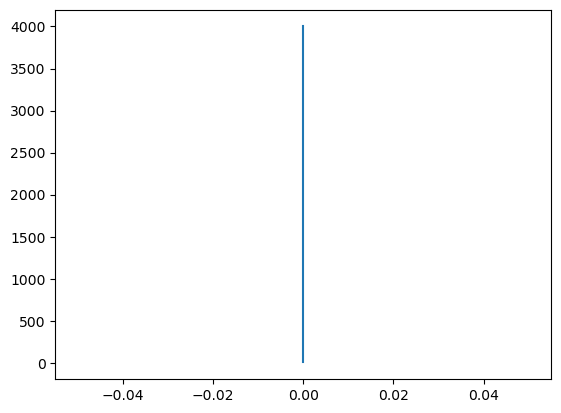

In [11]:
plt.plot( chi[:,13]==0,pres_vmp)

In [12]:

ridge1=np.arange(37,41)
ridge2=np.arange(47,78)
ridge= np.concatenate((ridge1, ridge2))

trans1=np.arange(8,24)
trans1=np.delete(trans1,np.arange(11,13)) # Deletes overestimated values in positions 11,12

trans2=np.arange(25,37)

trans3=np.array([0,1,3,5,6,7]) # South Cross-Ridge transect


pres2d = np.tile(dsvmp["pres"][0,:],(78,1)).T.astype(float)


In [13]:
dsvmp["pres2d"] = pres2d
dsvmp["epsilon"] = epsilon
dsvmp["chi"] = chi
dsvmp["longitude"] = lon_vmp
dsvmp["latitude"] = lat_vmp
dsvmp["T"] = T
dsvmp["salinity"] = salinity
dsvmp["theta"] = theta
dsvmp["gamman"] = gamman
dsvmp["oxygen"] = oxygen
dsvmp["grT"] = grT
dsvmp["grS"] = grS
dsvmp["grO"] = grO
io.savemat("RREX2017.mat", dsvmp)

dsvmp["pres2d"] = pres2d[:,ridge]
dsvmp["epsilon"] = epsilon[:,ridge]
dsvmp["chi"] = chi[:,ridge]
dsvmp["longitude"] = lon_vmp[ridge]
dsvmp["latitude"] = lat_vmp[ridge]
dsvmp["T"] = T[:,ridge]
dsvmp["salinity"] = salinity[:,ridge]
dsvmp["theta"] = theta[:,ridge]
dsvmp["gamman"] = gamman[:,ridge]
dsvmp["oxygen"] = oxygen[:,ridge]
dsvmp["grT"] = grT[:,ridge]
dsvmp["grS"] = grS[:,ridge]
dsvmp["grO"] = grO[:,ridge]
io.savemat("RREX2017_Ridge_Merged.mat",dsvmp)

dsvmp["pres2d"] = pres2d[:,trans1]
dsvmp["epsilon"] = epsilon[:,trans1]
dsvmp["chi"] = chi[:,trans1]
dsvmp["longitude"] = lon_vmp[trans1]
dsvmp["latitude"] = lat_vmp[trans1]
dsvmp["T"] = T[:,trans1]
dsvmp["salinity"] = salinity[:,trans1]
dsvmp["theta"] = theta[:,trans1]
dsvmp["gamman"] = gamman[:,trans1]
dsvmp["oxygen"] = oxygen[:,trans1]
dsvmp["grT"] = grT[:,trans1]
dsvmp["grS"] = grS[:,trans1]
dsvmp["grO"] = grO[:,trans1]
io.savemat("RREX2017_XRidge_Merged.mat",dsvmp)

dsvmp["pres2d"] = pres2d[:,trans2]
dsvmp["epsilon"] = epsilon[:,trans2]
dsvmp["chi"] = chi[:,trans2]
dsvmp["longitude"] = lon_vmp[trans2]
dsvmp["latitude"] = lat_vmp[trans2]
dsvmp["T"] = T[:,trans2]
dsvmp["salinity"] = salinity[:,trans2]
dsvmp["theta"] = theta[:,trans2]
dsvmp["gamman"] = gamman[:,trans2]
dsvmp["oxygen"] = oxygen[:,trans2]
dsvmp["grT"] = grT[:,trans2]
dsvmp["grS"] = grS[:,trans2]
dsvmp["grO"] = grO[:,trans2]
io.savemat("RREX2017_WRidge_Merged.mat",dsvmp)

dsvmp["pres2d"] = pres2d[:,trans3]
dsvmp["epsilon"] = epsilon[:,trans3]
dsvmp["chi"] = chi[:,trans3]
dsvmp["longitude"] = lon_vmp[trans3]
dsvmp["latitude"] = lat_vmp[trans3]
dsvmp["T"] = T[:,trans3]
dsvmp["salinity"] = salinity[:,trans3]
dsvmp["theta"] = theta[:,trans3]
dsvmp["gamman"] = gamman[:,trans3]
dsvmp["oxygen"] = oxygen[:,trans3]
dsvmp["grT"] = grT[:,trans3]
dsvmp["grS"] = grS[:,trans3]
dsvmp["grO"] = grO[:,trans3]
io.savemat("RREX2017_SouthXRidge_Merged.mat",dsvmp)

/opt/conda/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:319: MatWriteWarning: Starting field name with a underscore (__header__) is ignored
  MW.put_variables(mdict)
/opt/conda/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:319: MatWriteWarning: Starting field name with a underscore (__version__) is ignored
  MW.put_variables(mdict)
/opt/conda/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:319: MatWriteWarning: Starting field name with a underscore (__globals__) is ignored
  MW.put_variables(mdict)
